# 특징 디스크립터 검출기
- SIFT (Scale-Invariant Feature Transform)
- SURF (Speeded Up Robust Features)
- ORB (Oriented and Rotated BRIEF)

#### 라이브러리

In [199]:
# installs
!pip install pytesseract
!pip install pafy
!pip install youtube_dl


# pytorch
import torch


# OpenCV, OCR
import cv2
import pytesseract
from skimage.transform import resize


# Youtube video
import pafy
import cv2


# Visualizatipn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rc('font', family='malgun gothic')
plt.rc('axes', unicode_minus=False)

# time
from time import time

#### 차량 진입 사진 로드

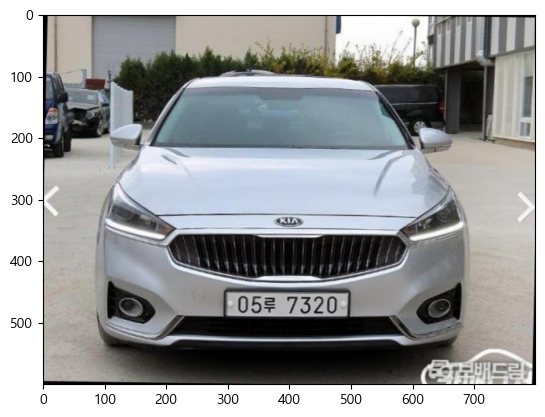

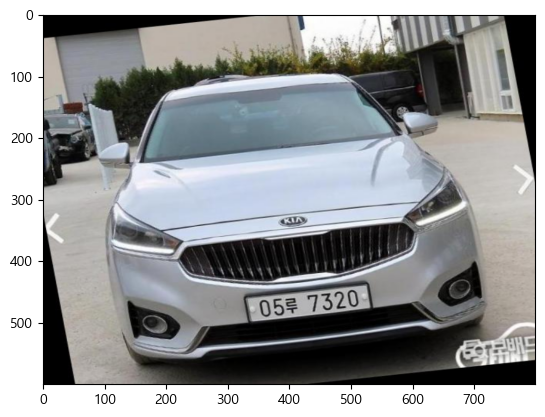

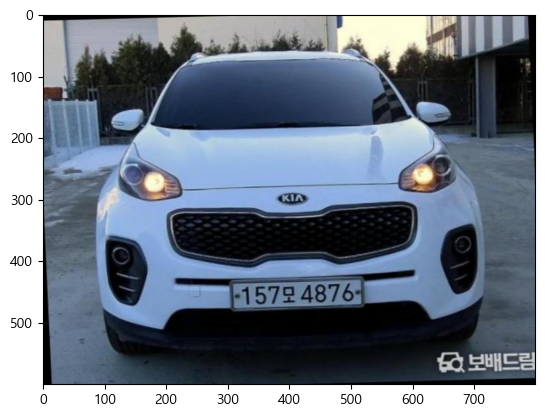

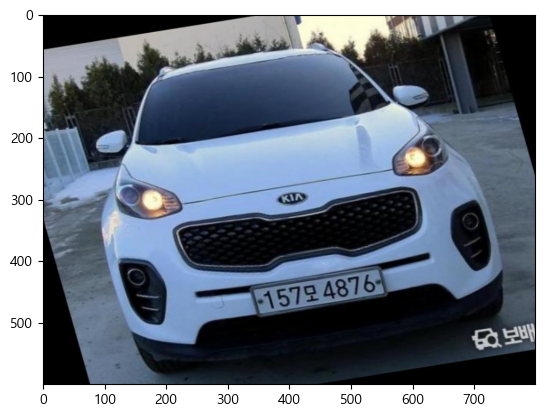

In [202]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# imread 함수 정의: 이미지 로드 및 크기 조정
def imread(filename, flags=cv2.IMREAD_COLOR, dtype=np.uint8, resize_dim=(800, 600)):
    """
    파일 경로를 읽어 이미지를 로드하고, 크기를 조정합니다.
    :param filename: 이미지 파일 경로
    :param flags: OpenCV 이미지 로드 플래그 (기본값: cv2.IMREAD_COLOR)
    :param dtype: 데이터 타입 (기본값: np.uint8)
    :param resize_dim: 이미지 크기 조정 (너비, 높이)
    :return: 로드된 이미지 또는 None
    """
    try:
        n = np.fromfile(filename, dtype)  # 한글 경로 지원을 위해 np.fromfile 사용
        img = cv2.imdecode(n, flags)     # 이미지 디코딩
        if img is not None and resize_dim:  # 이미지가 로드되었고 크기 조정 설정이 있을 때
            img = cv2.resize(img, resize_dim)
        return img
    except Exception as e:
        print(f"Error reading file {filename}: {e}")
        return None

# 이미지 파일 경로 설정
file1 = r"C:\Users\User\Documents\박준성\whitecar1.jpg"
file2 = r"C:\Users\User\Documents\박준성\whitecar2.jpg"
file3 = r"C:\Users\User\Documents\박준성\lightcar1.jpg"
file4 = r"C:\Users\User\Documents\박준성\lightcar2.jpg"

# 이미지 로드
whitecar01 = imread(file1, resize_dim=(800, 600))  # 크기를 800x600으로 조정
whitecar02 = imread(file2, resize_dim=(800, 600))  # 크기를 800x600으로 조정
lightcar01 = imread(file3, resize_dim=(800, 600))     # 크기를 800x600으로 조정
lightcar02 = imread(file4, resize_dim=(800, 600))     # 크기를 800x600으로 조정

# 이미지 출력
plt.imshow(cv2.cvtColor(whitecar01, cv2.COLOR_BGR2RGB))
plt.show()

plt.imshow(cv2.cvtColor(whitecar02, cv2.COLOR_BGR2RGB))
plt.show()

plt.imshow(cv2.cvtColor(lightcar01, cv2.COLOR_BGR2RGB))
plt.show()

plt.imshow(cv2.cvtColor(lightcar02, cv2.COLOR_BGR2RGB))
plt.show()


In [204]:
import numpy as np

In [206]:
car_images = [whitecar01, whitecar02, lightcar01, lightcar02]

#### SIFT (Scale-Invariant Feature Transform)

keypoint: 1936, descriptor: (1936, 128)
[[28. 10. 17. ...  0.  0.  0.]
 [ 6.  0.  0. ... 22. 63.  0.]
 [12.  0.  0. ... 13.  8.  0.]
 ...
 [ 4.  0.  2. ...  0.  0.  0.]
 [ 0.  0.  0. ...  9.  0.  0.]
 [30.  0.  1. ...  0.  0.  0.]]


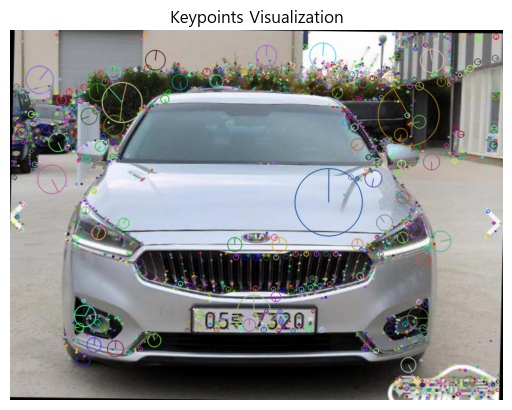

keypoint: 1871, descriptor: (1871, 128)
[[ 0.  0.  0. ...  2.  3.  0.]
 [ 1.  2. 17. ...  1.  1.  2.]
 [10. 16. 49. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... 24.  0.  0.]
 [ 0.  0.  0. ...  6.  1.  0.]
 [ 0.  0.  0. ...  1. 14. 65.]]


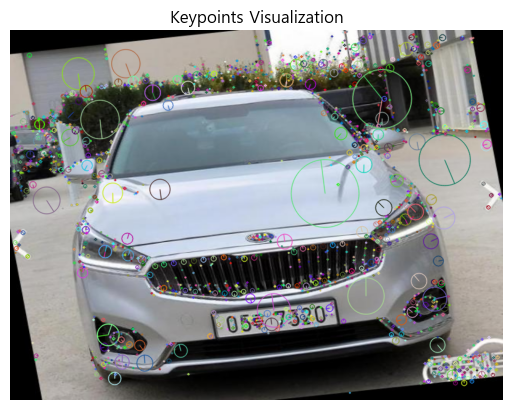

keypoint: 1578, descriptor: (1578, 128)
[[  0.   0.   0. ...   9.  63.  10.]
 [ 12.   5.   0. ...   0.   2.  14.]
 [  1.   1.   0. ...  10.  28.   5.]
 ...
 [  4.   1.   0. ...   0.  24.  26.]
 [  0.   2.  18. ...   3.   0.   0.]
 [  0.   0.   0. ...   2. 138.  46.]]


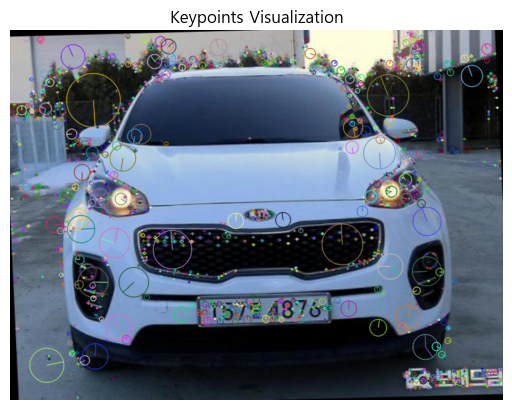

keypoint: 1550, descriptor: (1550, 128)
[[  0.   0.   0. ...   0.   0.   0.]
 [  0.   0.   0. ...   0.   0.   0.]
 [  0.  22. 145. ...   0.   0.   0.]
 ...
 [  0.   0.   0. ...   5.   3.   6.]
 [137.  15.   1. ...   0.   0.   0.]
 [  0.   0.   0. ...   4.   0.   0.]]


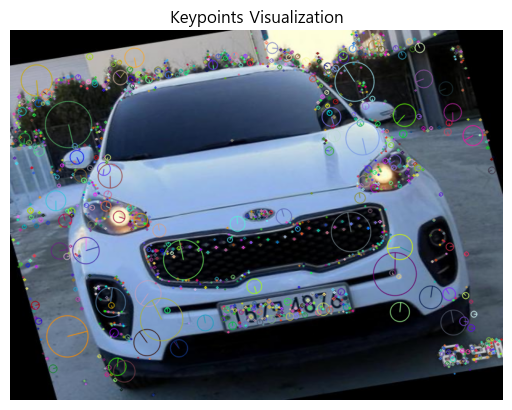

In [209]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# SIFT 추출기 생성 (최신 및 구버전 호환)
def create_sift():
    try:
        return cv2.SIFT_create()  # 최신 OpenCV (4.4.0 이상)
    except AttributeError:
        return cv2.xfeatures2d.SIFT_create()  # 구버전 OpenCV (4.4.0 미만)

# 이미지 리스트
car_images = [whitecar01, whitecar02, lightcar01, lightcar02]

# SIFT 객체 생성
sift = create_sift()

# SIFT 특징점 검출 및 디스크립터 계산
for car_image in car_images:
    # 이미지 복사
    copy_img = car_image.copy()
    
    # 이미지를 그레이스케일로 변환
    gray = cv2.cvtColor(copy_img, cv2.COLOR_BGR2GRAY)

    # SIFT로 키포인트 및 디스크립터 계산
    keypoints, descriptor = sift.detectAndCompute(gray, None)
    
    # 키포인트 및 디스크립터 정보 출력
    print(f'keypoint: {len(keypoints)}, descriptor: {descriptor.shape}')
    print(descriptor)

    # 키포인트를 이미지에 그리기
    draw_img = cv2.drawKeypoints(
        copy_img,
        keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    
    # 결과 시각화
    plt.imshow(cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Keypoints Visualization")
    plt.axis('off')
    plt.show()


#### SURF (Speeded Up Robust Features)

In [212]:
# 현재 openCV 버전이 4.4.0이상여서 SURF는 지원하지 않습니다.

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 리스트 (예: whitecar01, whitecar02 등)
car_images = [whitecar01, whitecar02, lightcar01, lightcar02]

# SURF 추출기 생성 ( 경계:1000, 피라미드:3, 서술자확장:True, 방향적용:True)
try:
    surf = cv2.xfeatures2d.SURF_create(1000, 3, True, True)
except AttributeError:
    print("SURF is not available in this OpenCV version. Please install 'opencv-contrib-python==4.2.0.32'.")

for car_image in car_images:
    if car_image is None:
        print("Image not loaded. Skipping...")
        continue

    # 이미지 복사 및 그레이스케일 변환
    copy_img = car_image.copy()
    gray = cv2.cvtColor(copy_img, cv2.COLOR_BGR2GRAY)

    # 키 포인트 검출 및 서술자 계산
    keypoints, desc = surf.detectAndCompute(gray, None)
    print(desc.shape, desc)

    # 키포인트 이미지에 그리기
    draw_img = cv2.drawKeypoints(
        copy_img, 
        keypoints, 
        None, 
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    # 결과 출력
    plt.imshow(cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB))
    plt.title("SURF Keypoints")
    plt.axis('off')
    plt.show()


SURF is not available in this OpenCV version. Please install 'opencv-contrib-python==4.2.0.32'.


NameError: name 'surf' is not defined

#### ORB (Oriented and Rotated BRIEF)

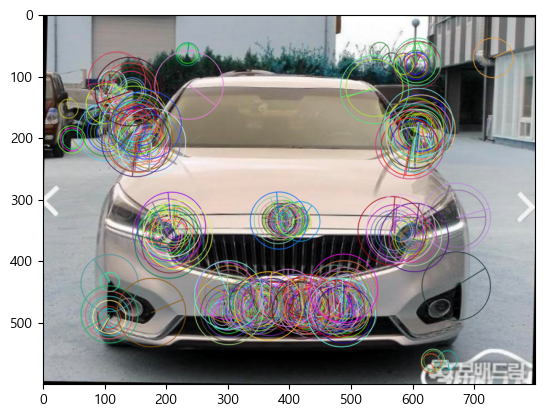

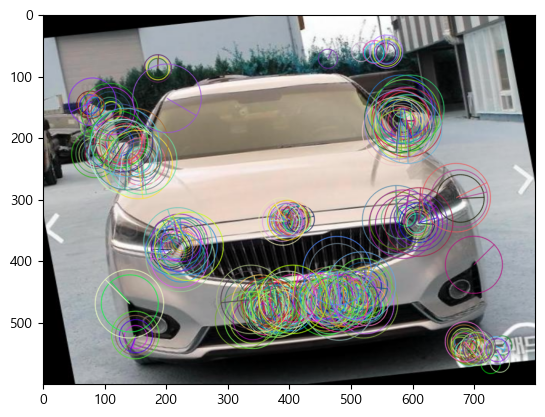

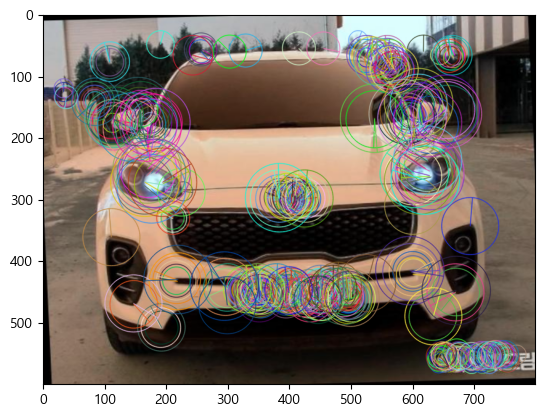

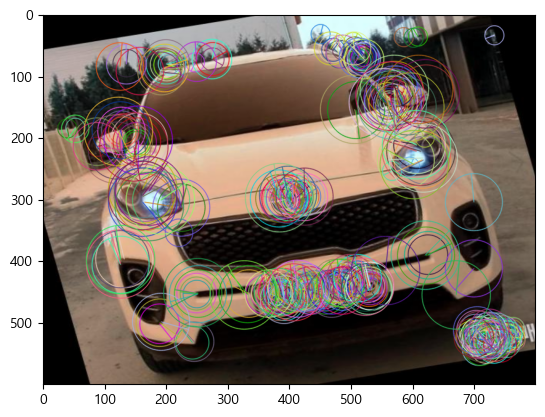

In [215]:
for car_image in car_images:

    # ORB로 특징점 및 특징 디스크립터 검출 (desc_orb.py)
    copy_img = car_image.copy()
    gray = cv2.cvtColor(copy_img, cv2.COLOR_BGR2GRAY)

    # ORB 추출기 생성
    orb = cv2.ORB_create()
    # 키 포인트 검출과 서술자 계산
    keypoints, descriptor = orb.detectAndCompute(copy_img, None)
    # 키 포인트 그리기
    draw_img = cv2.drawKeypoints(copy_img, keypoints, None, \
                 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    # 결과 출력
    plt.imshow(draw_img)
    plt.show()

create_sift 초기화 중...
create_surf 초기화 중...
현재 OpenCV 버전에서는 create_surf를 사용할 수 없습니다.
create_orb 초기화 중...

SIFT로 처리 중...
특징점 개수: 1936, 디스크립터 크기: (1936, 128)


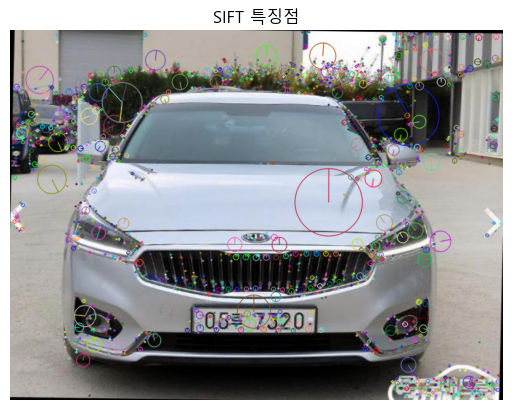

특징점 개수: 1871, 디스크립터 크기: (1871, 128)


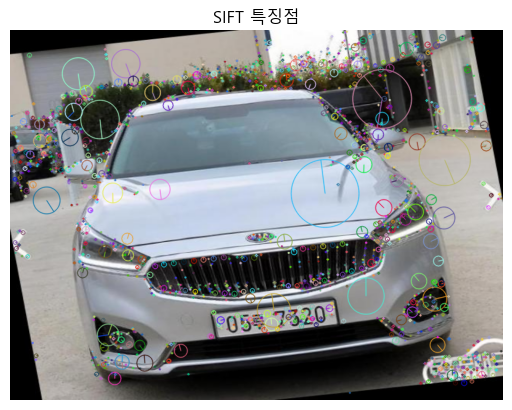

특징점 개수: 1578, 디스크립터 크기: (1578, 128)


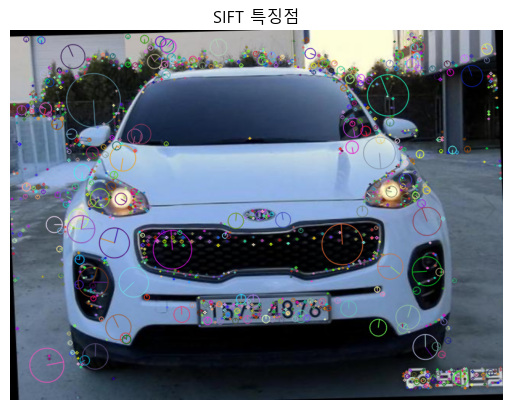

특징점 개수: 1550, 디스크립터 크기: (1550, 128)


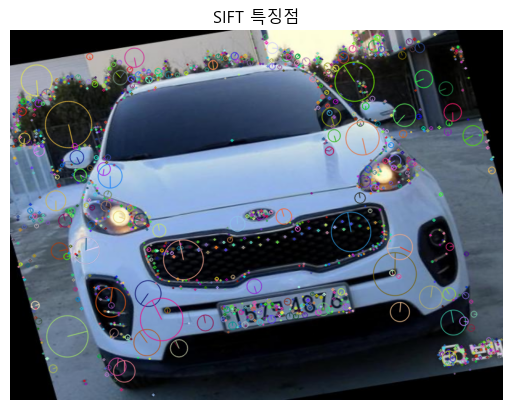


SURF로 처리 중...
검출기를 사용할 수 없습니다. 건너뜁니다...
검출기를 사용할 수 없습니다. 건너뜁니다...
검출기를 사용할 수 없습니다. 건너뜁니다...
검출기를 사용할 수 없습니다. 건너뜁니다...

ORB로 처리 중...
특징점 개수: 500, 디스크립터 크기: (500, 32)


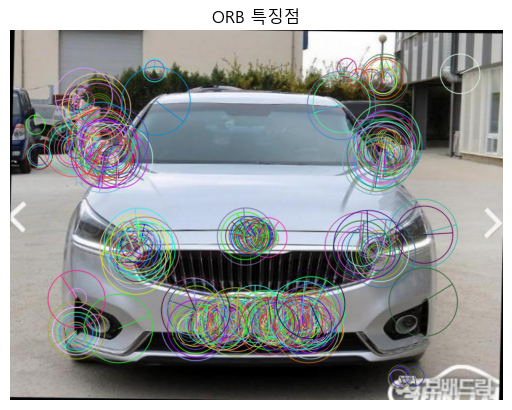

특징점 개수: 500, 디스크립터 크기: (500, 32)


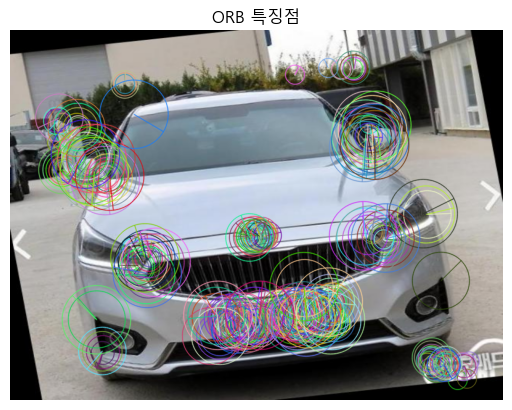

특징점 개수: 500, 디스크립터 크기: (500, 32)


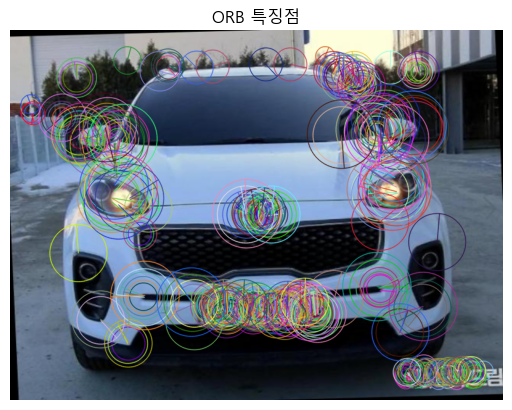

특징점 개수: 500, 디스크립터 크기: (500, 32)


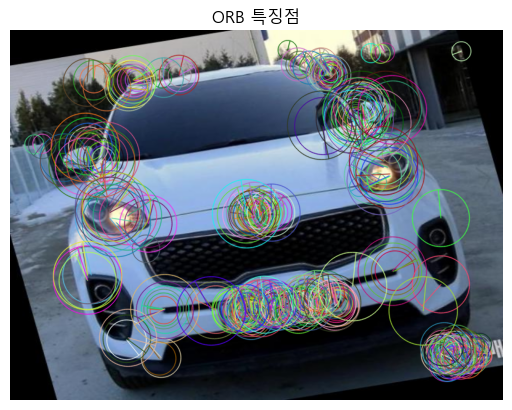

In [223]:
"""데코레이터를 사용하여 SIFT, SURF, ORB를 한 번에 실행"""
## SURF도 가능하지만 OpenCV 버전이 맞지 않아 출력되지 않습니다. 버전을 낮추면 다른 코드가 오류를 일으킬 수 있어 현재 상태로 유지합니다.
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 특징점 검출기 생성 데코레이터
def feature_detector(detector_func):
    """특징점 검출기 생성 및 예외 처리 데코레이터"""
    def wrapper(*args, **kwargs):
        try:
            print(f"{detector_func.__name__} 초기화 중...")
            return detector_func(*args, **kwargs)
        except AttributeError:
            print(f"현재 OpenCV 버전에서는 {detector_func.__name__}를 사용할 수 없습니다.")
            return None
    return wrapper

# SIFT 생성 함수
@feature_detector
def create_sift():
    return cv2.SIFT_create()

# SURF 생성 함수
@feature_detector
def create_surf():
    return cv2.xfeatures2d.SURF_create(1000, 3, True, True)

# ORB 생성 함수
@feature_detector
def create_orb():
    return cv2.ORB_create()

# 디스크립터 계산 함수
def compute_and_draw_keypoints(detector, image):
    """
    주어진 검출기로 특징점과 디스크립터를 계산하고 시각화
    :param detector: 특징점 검출기 (SIFT, SURF, ORB 등)
    :param image: 입력 이미지
    :return: 키포인트가 그려진 이미지
    """
    if detector is None:
        print("검출기를 사용할 수 없습니다. 건너뜁니다...")
        return None

    # 이미지를 그레이스케일로 변환
    gray = cv2.cvtColor(image.copy(), cv2.COLOR_BGR2GRAY)
    
    # 특징점과 디스크립터 계산
    keypoints, descriptor = detector.detectAndCompute(gray, None)
    if descriptor is not None:
        print(f"특징점 개수: {len(keypoints)}, 디스크립터 크기: {descriptor.shape}")
    else:
        print("디스크립터를 찾을 수 없습니다.")
    
    # 키포인트를 이미지에 그리기
    draw_img = cv2.drawKeypoints(
        image,
        keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    return draw_img

# 이미지 리스트 (사용할 이미지 설정)
car_images = [whitecar01, whitecar02, lightcar01, lightcar02]

# 검출기 생성
sift = create_sift()
surf = create_surf()
orb = create_orb()

# 각 검출기를 사용해 이미지 처리
for detector, name in zip([sift, surf, orb], ["SIFT", "SURF", "ORB"]):
    print(f"\n{name}로 처리 중...")
    for car_image in car_images:
        if car_image is None:
            print("이미지를 불러올 수 없습니다. 건너뜁니다...")
            continue

        result_img = compute_and_draw_keypoints(detector, car_image)
        if result_img is not None:
            # 결과 시각화
            plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
            plt.title(f"{name} 특징점")
            plt.axis('off')
            plt.show()


### 1. SIFT (Scale-Invariant Feature Transform)
#### 핵심 설명: SIFT는 이미지에서 스케일과 회전 변환에 강한 특징점을 추출하고 이를 기반으로 서술자를 생성하는 알고리즘입니다. 이미지의 주요 키포인트를 검출하고, 해당 키포인트의 주변 정보를 서술자로 저장하여 이미지 매칭 및 객체 인식에 활용됩니다.
#### 알아두어야 할 점: SIFT는 강력한 특징 추출 알고리즘으로 회전 불변성과 스케일 불변성을 제공합니다. 하지만 계산 비용이 높아 실시간 시스템에는 적합하지 않을 수 있습니다. OpenCV 4.4.0 이상에서는 기본 라이브러리에 포함되어 있으나, 그 이전 버전에서는 opencv-contrib-python 설치가 필요합니다.

### 2. SURF (Speeded Up Robust Features)
#### 핵심 설명: SURF는 SIFT를 개선하여 빠른 계산 속도를 제공하는 알고리즘입니다. Hessian 행렬 기반으로 특징점을 검출하며 스케일과 회전에 불변한 서술자를 생성합니다. 빠른 계산을 위해 Haar 웨이브릿 변환을 사용하여 특징을 추출합니다.
#### 알아두어야 할 점: SURF는 SIFT보다 빠르지만, OpenCV 최신 버전(4.4.0 이상)에서는 기본 지원하지 않습니다. 사용하려면 opencv-contrib-python의 구버전(예: 4.2.0.32)을 설치해야 합니다. 계산 속도가 빠르다는 장점이 있지만 상용 환경에서는 SIFT와 마찬가지로 특허 문제가 있을 수 있습니다.

### 3. ORB (Oriented and Rotated BRIEF)
#### 핵심 설명: ORB는 SIFT와 SURF의 대안으로 개발된 특징점 검출 및 서술자 생성 알고리즘으로 회전 불변성과 부분적인 스케일 불변성을 제공합니다. FAST를 기반으로 특징점을 검출하고 BRIEF를 확장하여 서술자를 생성합니다. 계산 효율성이 높아 실시간 애플리케이션에 적합합니다.
#### 알아두어야 할 점: ORB는 속도가 빠르고 SIFT 및 SURF에 비해 계산 비용이 낮습니다. 하지만 스케일 변화에 대한 완전한 불변성을 제공하지 않으며 복잡한 이미지 환경에서는 성능이 떨어질 수 있습니다. OpenCV 기본 라이브러리에 포함되어 있어 추가 설치 없이 사용 가능합니다.

### 3. ORB (Oriented and Rotated BRIEF)
#### 핵심 설명: ORB는 SIFT와 SURF의 대안으로 개발된 특징점 검출 및 서술자 생성 알고리즘으로 회전 불변성과 부분적인 스케일 불변성을 제공합니다. FAST를 기반으로 특징점을 검출하고 BRIEF를 확장하여 서술자를 생성합니다. 계산 효율성이 높아 실시간 애플리케이션에 적합합니다.
#### 알아두어야 할 점: ORB는 속도가 빠르고 SIFT 및 SURF에 비해 계산 비용이 낮습니다. 하지만 스케일 변화에 대한 완전한 불변성을 제공하지 않으며 복잡한 이미지 환경에서는 성능이 떨어질 수 있습니다. OpenCV 기본 라이브러리에 포함되어 있어 추가 설치 없이 사용 가능합니다.

### 요약
#### SIFT는 회전과 스케일에 강한 높은 정확도의 알고리즘이지만, 계산 비용이 높습니다. SURF는 SIFT보다 빠르고 효율적이며, 스케일과 회전 불변성을 제공하지만 최신 OpenCV에서 지원되지 않습니다. ORB는 빠르고 경량화된 알고리즘으로 실시간 처리에 적합하지만, 스케일 변화에는 다소 민감합니다.
#### 각 알고리즘은 속도와 정확도에서 차이가 있으므로, 데이터 특성과 목적에 따라 SIFT와 SURF는 정밀 작업에, ORB는 실시간 애플리케이션에 적합합니다.